# HW10-11: Компьютерное зрение в PyTorch

> Часть A: классификация изображений (STL10), эксперименты C1-C4.

> Часть B: segmentation track (OxfordIIITPet), режимы V1-V2.

## 2.4.1 Импорты, seed и устройство

In [ ]:
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

try:
    from torchvision.models import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
except ImportError:
    from torchvision.models.segmentation import (
        deeplabv3_resnet50,
        DeepLabV3_ResNet50_Weights,
    )

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Устройство
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    '''elif torch.backends.mps.is_available():
    # для Mac 
    DEVICE = torch.device("mps")
    torch.backends.mps.benchmark = False
    torch.backends.mps.deterministic = True'''
else:
    DEVICE = torch.device("cpu")
    torch.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# Папки
DATA_ROOT = Path("./data")
ARTIFACTS_DIR = Path("./artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")

PyTorch 2.10.0 | torchvision 0.25.0
Device: cpu
Seed: 42


## 2.4.2 Данные и DataLoader

Используем STL10 (рекомендованный датасет) через torchvision, делаем фиксированное train/val разбиение 80/20 и готовим три набора transforms:
- базовый для CNN
- с аугментациями для CNN
- preprocessing для pretrained ResNet18

100.0%


Train/Val/Test sizes: 4000/1000/8000
x.shape = (128, 3, 96, 96) | y.shape = (128,)
Classes: 10


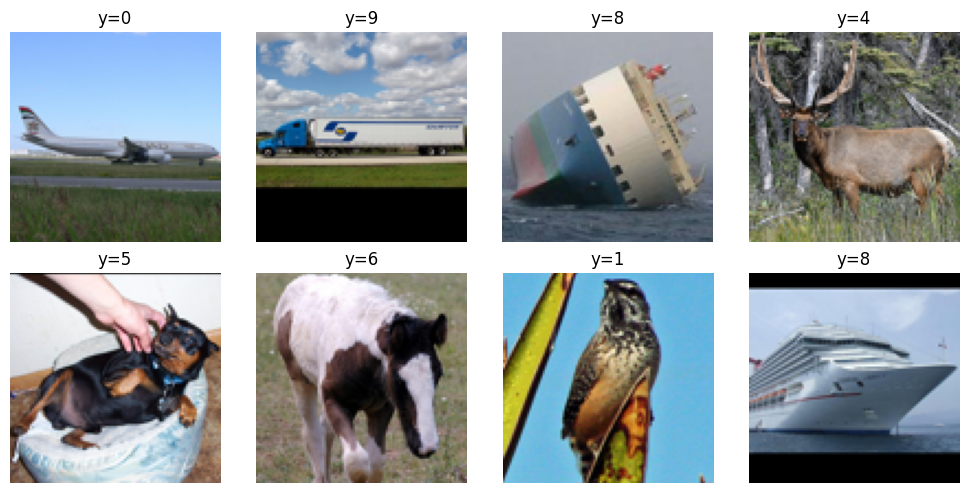

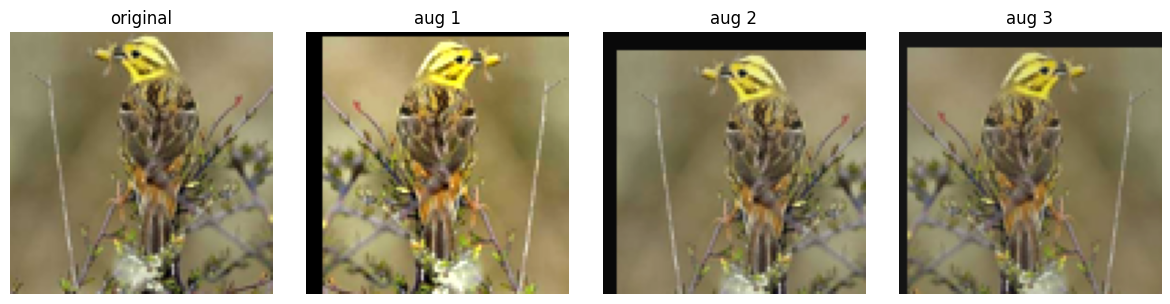

Saved: artifacts/figures/augmentations_preview.png


In [ ]:
# Параметры
BATCH_SIZE = 256 if DEVICE.type in ('cuda', 'mps') else 128
NUM_WORKERS = 2
NUM_CLASSES_A = 10

# Трансформация
transform_cnn_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transform_cnn_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
# Параметры ResNet
resnet_weights = ResNet18_Weights.DEFAULT
transform_resnet = resnet_weights.transforms()

# Тренироваочный и валидационные датасеты
full_train_for_split = torchvision.datasets.STL10(
    root=str(DATA_ROOT), split="train", download=True, transform=transform_cnn_base
)

n_total = len(full_train_for_split)
n_train = int(0.8 * n_total)
perm = torch.randperm(n_total, generator=torch.Generator().manual_seed(SEED)).tolist()
train_idx = perm[:n_train]
val_idx = perm[n_train:]

def build_classification_loaders(train_transform, eval_transform):
    train_base = torchvision.datasets.STL10(
        root=str(DATA_ROOT), split="train", download=True, transform=train_transform
    )
    val_base = torchvision.datasets.STL10(
        root=str(DATA_ROOT), split="train", download=True, transform=eval_transform
    )
    test_ds = torchvision.datasets.STL10(
        root=str(DATA_ROOT), split="test", download=True, transform=eval_transform
    )

    train_ds = Subset(train_base, train_idx)
    val_ds = Subset(val_base, val_idx)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
    )
    return train_loader, val_loader, test_loader

# Проверка батча для CNN
train_loader_base, val_loader_base, test_loader_base = build_classification_loaders(
    train_transform=transform_cnn_base,
    eval_transform=transform_cnn_base,
)

x_batch, y_batch = next(iter(train_loader_base))
print(f"Train/Val/Test sizes: {len(train_idx)}/{len(val_idx)}/{len(test_loader_base.dataset)}")
print(f"x.shape = {tuple(x_batch.shape)} | y.shape = {tuple(y_batch.shape)}")
print(f"Classes: {NUM_CLASSES_A}")

# Просмотр примеров изображений
inv_norm = transforms.Normalize(
    mean=[-1.0, -1.0, -1.0],
    std=[2.0, 2.0, 2.0],
)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img_t, label in zip(axes.flatten(), x_batch[:8], y_batch[:8]):
    img = inv_norm(img_t).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    ax.set_title(f"y={int(label)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Визуализация аугментаций (обязательный артефакт)
raw_preview_ds = torchvision.datasets.STL10(
    root=str(DATA_ROOT), split="train", download=True, transform=None
)
sample_img, _ = raw_preview_ds[0]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample_img)
axes[0].set_title("original")
axes[0].axis("off")

for i in range(1, 4):
    aug = transform_cnn_aug(sample_img)
    aug_img = inv_norm(aug).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(aug_img)
    axes[i].set_title(f"aug {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=150)
plt.show()
print("Saved: artifacts/figures/augmentations_preview.png")

## 2.4.3 Базовые функции обучения и оценки

Реализуем `train_one_epoch(...)`, `evaluate(...)`, историю обучения и 4 обязательных эксперимента C1-C4.

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total


def fit_classifier(model, train_loader, val_loader, epochs, optimizer, criterion, device):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"epoch {epoch:02d}/{epochs} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
            f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}"
        )

    return history, best_state, best_val_acc

## 3.1 Часть A: эксперименты C1-C4

- C1: simple-cnn-base (без аугментаций)
- C2: simple-cnn-aug (та же CNN + аугментации)
- C3: resnet18-head-only (заморожен backbone)
- C4: resnet18-finetune (разморожены layer4 + fc)

In [ ]:
criterion_cls = nn.CrossEntropyLoss()
EPOCHS_CNN = 5
EPOCHS_RESNET = 3

classification_histories = {}
classification_rows = []

def run_classification_experiment(
    experiment_id, model, train_loader, val_loader, optimizer, epochs, dataset_name="STL10"
 ):
    model = model.to(DEVICE)
    history, best_state, best_val_acc = fit_classifier(
        model, train_loader, val_loader, epochs, optimizer, criterion_cls, DEVICE
    )
    classification_histories[experiment_id] = history

    row = {
        "experiment_id": experiment_id,
        "task": "classification",
        "dataset": dataset_name,
        "seed": SEED,
        "model_summary": type(model).__name__,
        "optimizer": type(optimizer).__name__,
        "lr": optimizer.param_groups[0]["lr"],
        "epochs_trained": epochs,
        "best_val_accuracy": float(best_val_acc),
        "test_accuracy": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": "",
    }
    classification_rows.append(row)
    return history, best_state, best_val_acc

# C1: simple-cnn-base (базовая CNN)
print("\n=== C1: simple-cnn-base ===")
train_loader_c1, val_loader_c1, test_loader_cnn = build_classification_loaders(
    train_transform=transform_cnn_base,
    eval_transform=transform_cnn_base,
 )
model_c1 = SimpleCNN(num_classes=NUM_CLASSES_A)
opt_c1 = optim.Adam(model_c1.parameters(), lr=1e-3)
hist_c1, state_c1, best_val_c1 = run_classification_experiment(
    "C1", model_c1, train_loader_c1, val_loader_c1, opt_c1, EPOCHS_CNN
 )

# C2: simple-cnn-aug (та же архитектура CNN)
print("\n=== C2: simple-cnn-aug ===")
train_loader_c2, val_loader_c2, _ = build_classification_loaders(
    train_transform=transform_cnn_aug,
    eval_transform=transform_cnn_base,
 )
model_c2 = SimpleCNN(num_classes=NUM_CLASSES_A)
opt_c2 = optim.Adam(model_c2.parameters(), lr=1e-3)
hist_c2, state_c2, best_val_c2 = run_classification_experiment(
    "C2", model_c2, train_loader_c2, val_loader_c2, opt_c2, EPOCHS_CNN
 )

# C3: resnet18-head-only (обучается только голова)
print("\n=== C3: resnet18-head-only ===")
train_loader_c3, val_loader_c3, test_loader_resnet = build_classification_loaders(
    train_transform=transform_resnet,
    eval_transform=transform_resnet,
 )
model_c3 = resnet18(weights=resnet_weights)
for p in model_c3.parameters():
    p.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, NUM_CLASSES_A)
for p in model_c3.fc.parameters():
    p.requires_grad = True
opt_c3 = optim.Adam(model_c3.fc.parameters(), lr=1e-3)
hist_c3, state_c3, best_val_c3 = run_classification_experiment(
    "C3", model_c3, train_loader_c3, val_loader_c3, opt_c3, EPOCHS_RESNET
 )

# C4: resnet18-finetune (дообучаем layer4 + fc)
print("\n=== C4: resnet18-finetune ===")
train_loader_c4, val_loader_c4, _ = build_classification_loaders(
    train_transform=transform_resnet,
    eval_transform=transform_resnet,
 )
model_c4 = resnet18(weights=resnet_weights)
for p in model_c4.parameters():
    p.requires_grad = False
for p in model_c4.layer4.parameters():
    p.requires_grad = True
model_c4.fc = nn.Linear(model_c4.fc.in_features, NUM_CLASSES_A)
for p in model_c4.fc.parameters():
    p.requires_grad = True
opt_c4 = optim.Adam((p for p in model_c4.parameters() if p.requires_grad), lr=1e-4)
hist_c4, state_c4, best_val_c4 = run_classification_experiment(
    "C4", model_c4, train_loader_c4, val_loader_c4, opt_c4, EPOCHS_RESNET
 )

print("\nBest val accuracies:")
print(f"C1={best_val_c1:.4f} | C2={best_val_c2:.4f} | C3={best_val_c3:.4f} | C4={best_val_c4:.4f}")


=== C1: simple-cnn-base ===
epoch 01/5 | train_loss=2.1840 train_acc=0.1760 | val_loss=2.0285 val_acc=0.2290
epoch 02/5 | train_loss=1.9741 train_acc=0.2622 | val_loss=1.9376 val_acc=0.2560
epoch 03/5 | train_loss=1.8958 train_acc=0.2790 | val_loss=1.8676 val_acc=0.2840
epoch 04/5 | train_loss=1.8225 train_acc=0.2998 | val_loss=1.8070 val_acc=0.3090
epoch 05/5 | train_loss=1.7722 train_acc=0.3105 | val_loss=1.7372 val_acc=0.3250

=== C2: simple-cnn-aug ===
epoch 01/5 | train_loss=2.2253 train_acc=0.1505 | val_loss=2.1053 val_acc=0.2300
epoch 02/5 | train_loss=2.0752 train_acc=0.2213 | val_loss=2.0148 val_acc=0.2570
epoch 03/5 | train_loss=2.0056 train_acc=0.2412 | val_loss=1.9589 val_acc=0.2630
epoch 04/5 | train_loss=1.9530 train_acc=0.2540 | val_loss=1.9341 val_acc=0.2650
epoch 05/5 | train_loss=1.8774 train_acc=0.2913 | val_loss=1.8258 val_acc=0.3070

=== C3: resnet18-head-only ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/cheese_makso/.cach

100.0%


epoch 01/3 | train_loss=1.3551 train_acc=0.6400 | val_loss=0.6715 val_acc=0.8940
epoch 02/3 | train_loss=0.5062 train_acc=0.9073 | val_loss=0.3954 val_acc=0.9250
epoch 03/3 | train_loss=0.3391 train_acc=0.9287 | val_loss=0.3247 val_acc=0.9340

=== C4: resnet18-finetune ===
epoch 01/3 | train_loss=0.7889 train_acc=0.7970 | val_loss=0.2997 val_acc=0.9150
epoch 02/3 | train_loss=0.1626 train_acc=0.9677 | val_loss=0.2309 val_acc=0.9380
epoch 03/3 | train_loss=0.0701 train_acc=0.9935 | val_loss=0.2110 val_acc=0.9450

Best val accuracies:
C1=0.3250 | C2=0.3070 | C3=0.9340 | C4=0.9450


In [ ]:
# Выбор лучшего классификатора по val_accuracy
state_map = {"C1": state_c1, "C2": state_c2, "C3": state_c3, "C4": state_c4}
val_map = {"C1": best_val_c1, "C2": best_val_c2, "C3": best_val_c3, "C4": best_val_c4}
best_exp = max(val_map, key=val_map.get)

if best_exp in ("C1", "C2"):
    best_model = SimpleCNN(num_classes=NUM_CLASSES_A).to(DEVICE)
    test_loader_best = test_loader_cnn
    best_transform_name = "cnn_base_norm"
elif best_exp == "C3":
    best_model = resnet18(weights=None)
    best_model.fc = nn.Linear(best_model.fc.in_features, NUM_CLASSES_A)
    best_model = best_model.to(DEVICE)
    test_loader_best = test_loader_resnet
    best_transform_name = "resnet_weights_transforms"
else:
    best_model = resnet18(weights=None)
    best_model.fc = nn.Linear(best_model.fc.in_features, NUM_CLASSES_A)
    best_model = best_model.to(DEVICE)
    test_loader_best = test_loader_resnet
    best_transform_name = "resnet_weights_transforms"

best_model.load_state_dict(state_map[best_exp])
test_loss_best, test_acc_best = evaluate(best_model, test_loader_best, criterion_cls, DEVICE)

for row in classification_rows:
    if row["experiment_id"] == best_exp:
        row["test_accuracy"] = float(test_acc_best)
        row["notes"] = "chosen_by_best_val_accuracy"
    if row["experiment_id"] == "C2":
        row["notes"] = "same_cnn_as_C1_with_augmentations"
    if row["experiment_id"] == "C3":
        row["notes"] = "resnet18_pretrained_head_only"
    if row["experiment_id"] == "C4":
        row["notes"] = "resnet18_pretrained_partial_finetune_layer4_fc"

print(f"Best experiment by val: {best_exp}")
print(f"Final test accuracy (used once): {test_acc_best:.4f}")

Best experiment by val: C4
Final test accuracy (used once): 0.9443


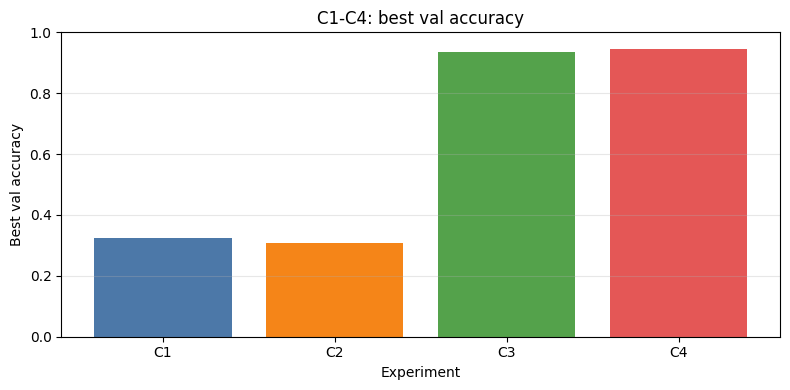

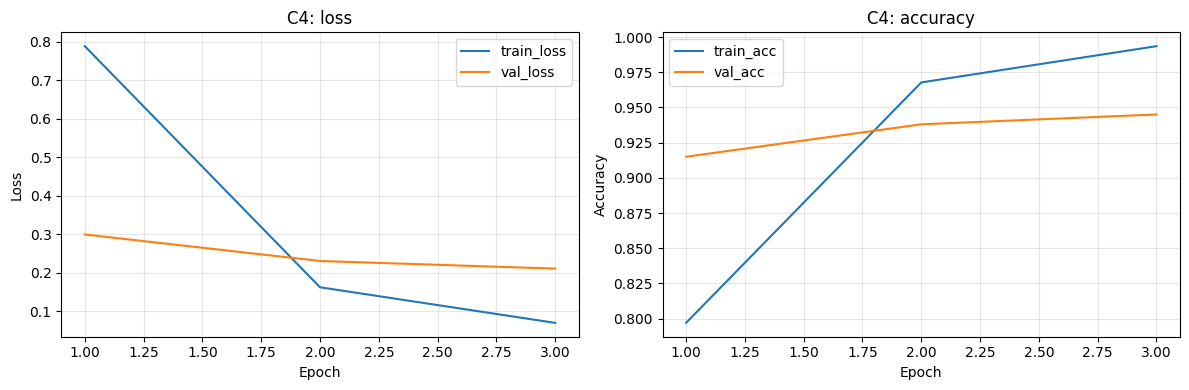

Saved: artifacts/figures/classification_compare.png
Saved: artifacts/figures/classification_curves_best.png


In [ ]:
# Построение обязательных графиков классификации
fig, ax = plt.subplots(figsize=(8, 4))
exp_order = ["C1", "C2", "C3", "C4"]
vals = [val_map[e] for e in exp_order]
ax.bar(exp_order, vals, color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
ax.set_title("C1-C4: best val accuracy")
ax.set_xlabel("Experiment")
ax.set_ylabel("Best val accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=150)
plt.show()

best_hist = classification_histories[best_exp]
epochs_best = range(1, len(best_hist["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_best, best_hist["train_loss"], label="train_loss")
axes[0].plot(epochs_best, best_hist["val_loss"], label="val_loss")
axes[0].set_title(f"{best_exp}: loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_best, best_hist["train_acc"], label="train_acc")
axes[1].plot(epochs_best, best_hist["val_acc"], label="val_acc")
axes[1].set_title(f"{best_exp}: accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150)
plt.show()
print("Saved: artifacts/figures/classification_compare.png")
print("Saved: artifacts/figures/classification_curves_best.png")

## 3.2 Часть B: Вариаент 2: segmentation track (датасет OxfordIIITPet), режимы V1-V2

Используем pretrained `DeepLabV3_ResNet50` и оцениваем два режима постобработки:
- V1: базовый порог
- V2: альтернативная постобработка (другой порог + морфологическая очистка)

In [ ]:
# Часть B: датасет и модель
pet_weights = DeepLabV3_ResNet50_Weights.DEFAULT
pet_preprocess = pet_weights.transforms()

pet_ds = torchvision.datasets.OxfordIIITPet(
    root=str(DATA_ROOT),
    split="test",
    target_types="segmentation",
    download=True,
 )

pet_model = deeplabv3_resnet50(weights=pet_weights).to(DEVICE)
pet_model.eval()

# В пространстве меток VOC для pretrained DeepLabV3: cat=8, dog=12
PET_CLASS_IDS = [8, 12]

def morph_cleanup(binary_mask_tensor):
    # Морфологическое закрытие через max-pool для уменьшения дыр/шума
    x = binary_mask_tensor.float().unsqueeze(0).unsqueeze(0)
    dil = torch.nn.functional.max_pool2d(x, kernel_size=3, stride=1, padding=1)
    ero = 1.0 - torch.nn.functional.max_pool2d(1.0 - dil, kernel_size=3, stride=1, padding=1)
    return (ero[0, 0] > 0.5)

@torch.no_grad()
def predict_pet_foreground(image_pil, threshold=0.5, use_cleanup=False):
    inp = pet_preprocess(image_pil).unsqueeze(0).to(DEVICE)
    logits = pet_model(inp)["out"][0]
    probs = torch.softmax(logits, dim=0)
    fg_prob = torch.stack([probs[i] for i in PET_CLASS_IDS], dim=0).max(dim=0).values

    pred = fg_prob >= threshold
    if use_cleanup:
        pred = morph_cleanup(pred)

    # Масштабируем предсказание до исходного размера изображения при необходимости
    h, w = image_pil.size[1], image_pil.size[0]
    pred_resized = torch.nn.functional.interpolate(
        pred.float().unsqueeze(0).unsqueeze(0), size=(h, w), mode="nearest"
    )[0, 0] > 0.5
    return pred_resized.cpu().numpy().astype(np.uint8)

def bin_metrics(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()
    union = np.logical_or(gt, pred).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    iou = tp / (union + 1e-9)
    return precision, recall, iou

# Оцениваем V1 и V2 на подвыборке для ускорения
N_EVAL = min(80, len(pet_ds))
indices_eval = list(range(N_EVAL))

def eval_segmentation_variant(threshold, use_cleanup):
    pr_list, rc_list, iou_list = [], [], []
    viz_pack = []

    for i in indices_eval:
        image, trimap = pet_ds[i]
        gt = (np.array(trimap) == 1).astype(np.uint8)  # foreground = тело питомца
        pred = predict_pet_foreground(image, threshold=threshold, use_cleanup=use_cleanup)

        precision, recall, iou = bin_metrics(gt, pred)
        pr_list.append(precision)
        rc_list.append(recall)
        iou_list.append(iou)

        if len(viz_pack) < 4:
            viz_pack.append((np.array(image), gt, pred))

    return {
        "precision": float(np.mean(pr_list)),
        "recall": float(np.mean(rc_list)),
        "mean_iou": float(np.mean(iou_list)),
        "examples": viz_pack,
    }

v1 = eval_segmentation_variant(threshold=0.50, use_cleanup=False)
v2 = eval_segmentation_variant(threshold=0.60, use_cleanup=True)

print("V1:", {k: round(v1[k], 4) for k in ["precision", "recall", "mean_iou"]})
print("V2:", {k: round(v2[k], 4) for k in ["precision", "recall", "mean_iou"]})

100.0%
100.0%


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /Users/cheese_makso/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


V1: {'precision': 0.7878, 'recall': 0.9701, 'mean_iou': 0.768}
V2: {'precision': 0.8058, 'recall': 0.9399, 'mean_iou': 0.7655}


## Figures

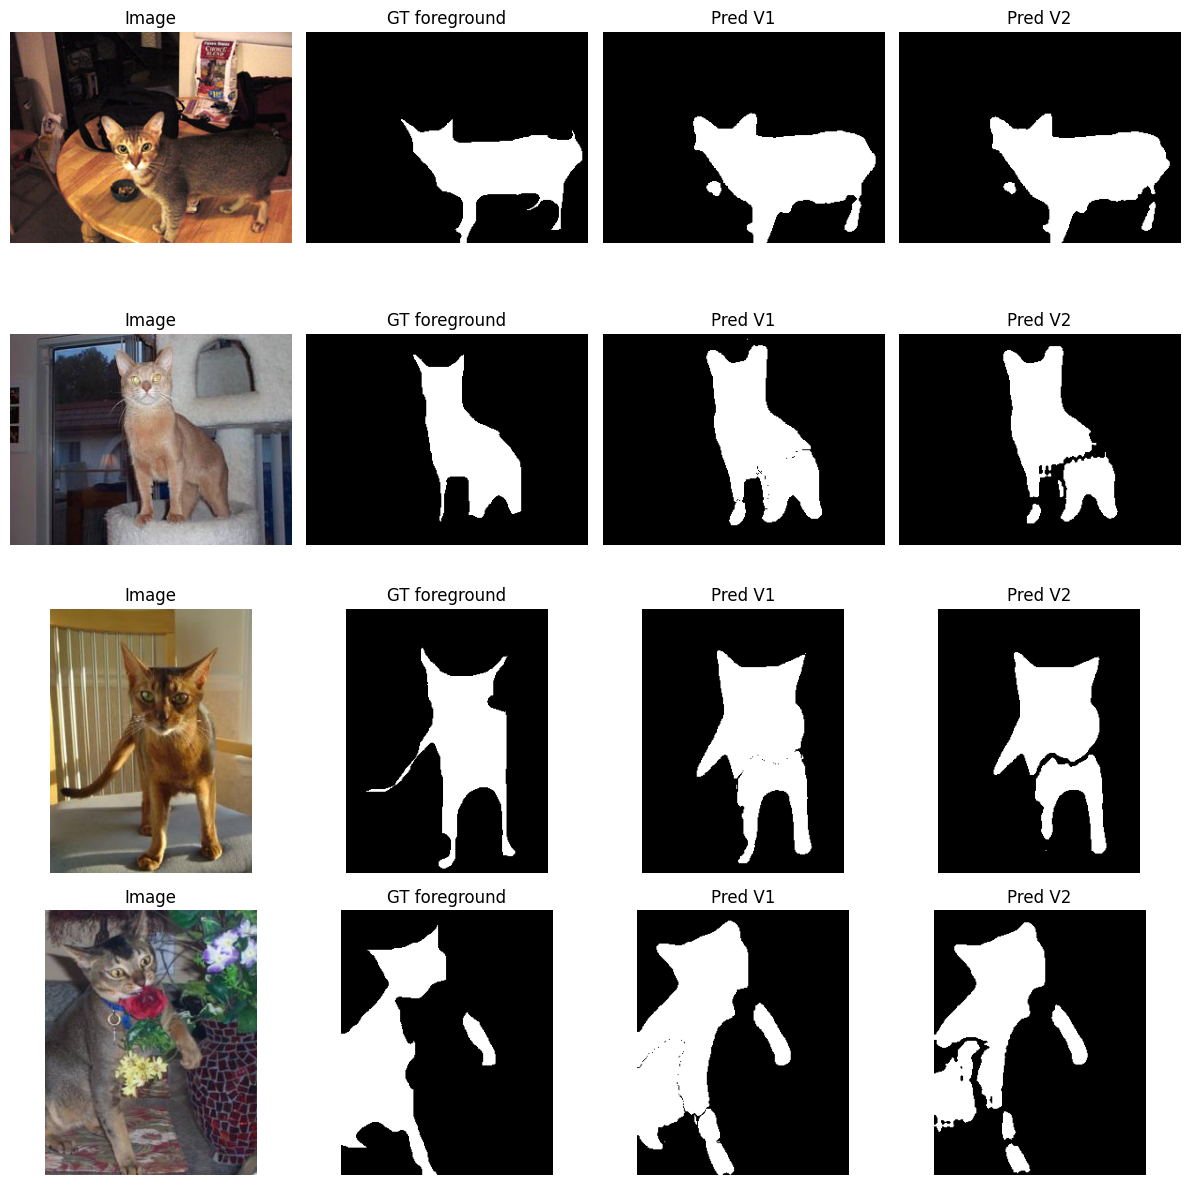

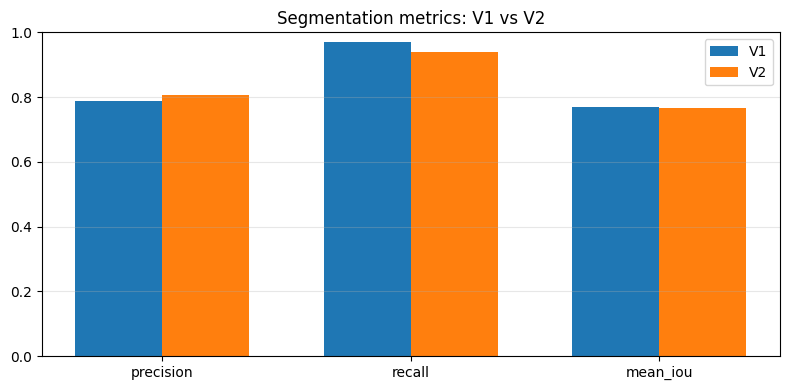

Saved: artifacts/figures/segmentation_examples.png
Saved: artifacts/figures/segmentation_metrics.png


In [ ]:
# Обязательные графики для segmentation track
examples = v1["examples"]

fig, axes = plt.subplots(len(examples), 4, figsize=(12, 3 * len(examples)))
if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)

for r, (img, gt, pred_v1) in enumerate(examples):
    # Пересчитываем V2 на том же изображении для сравнения рядом
    image_pil, _ = pet_ds[indices_eval[r]]
    pred_v2 = predict_pet_foreground(image_pil, threshold=0.60, use_cleanup=True)

    axes[r, 0].imshow(img)
    axes[r, 0].set_title("Image")
    axes[r, 1].imshow(gt, cmap="gray")
    axes[r, 1].set_title("GT foreground")
    axes[r, 2].imshow(pred_v1, cmap="gray")
    axes[r, 2].set_title("Pred V1")
    axes[r, 3].imshow(pred_v2, cmap="gray")
    axes[r, 3].set_title("Pred V2")

    for c in range(4):
        axes[r, c].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_examples.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
metric_names = ["precision", "recall", "mean_iou"]
x = np.arange(len(metric_names))
w = 0.35
ax.bar(x - w / 2, [v1[m] for m in metric_names], width=w, label="V1")
ax.bar(x + w / 2, [v2[m] for m in metric_names], width=w, label="V2")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
ax.legend()
ax.set_title("Segmentation metrics: V1 vs V2")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150)
plt.show()

print("Saved: artifacts/figures/segmentation_examples.png")
print("Saved: artifacts/figures/segmentation_metrics.png")

In [13]:
# Сохранение обязательных артефактов: лучший классификатор + конфиг + runs.csv

# 1) Сохраняем best_classifier.pt
torch.save(state_map[best_exp], ARTIFACTS_DIR / "best_classifier.pt")

# 2) Сохраняем best_classifier_config.json
best_config = {
    "dataset": "STL10",
    "seed": SEED,
    "chosen_experiment": best_exp,
    "architecture": "SimpleCNN" if best_exp in ("C1", "C2") else "ResNet18",
    "transforms": best_transform_name,
    "optimizer": "Adam",
    "lr": float(opt_c4.param_groups[0]["lr"]) if best_exp == "C4" else 1e-3,
    "epochs_trained": len(classification_histories[best_exp]["train_loss"]),
    "best_val_accuracy": float(val_map[best_exp]),
    "best_val_loss": float(min(classification_histories[best_exp]["val_loss"])),
    "test_accuracy": float(test_acc_best),
    "test_loss": float(test_loss_best),
}
with open(ARTIFACTS_DIR / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

# 3) Сохраняем runs.csv
seg_rows = [
    {
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_accuracy": np.nan,
        "test_accuracy": np.nan,
        "precision": v1["precision"],
        "recall": v1["recall"],
        "mean_iou": v1["mean_iou"],
        "notes": "threshold=0.50, basic postprocessing",
    },
    {
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": 0,
        "best_val_accuracy": np.nan,
        "test_accuracy": np.nan,
        "precision": v2["precision"],
        "recall": v2["recall"],
        "mean_iou": v2["mean_iou"],
        "notes": "threshold=0.60 + morphological cleanup",
    },
]

runs_df = pd.DataFrame(classification_rows + seg_rows)
runs_df = runs_df[
    [
        "experiment_id", "task", "dataset", "seed",
        "model_summary", "optimizer", "lr", "epochs_trained",
        "best_val_accuracy", "test_accuracy",
        "precision", "recall", "mean_iou", "notes",
    ]
]
runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)

print("Saved: artifacts/best_classifier.pt")
print("Saved: artifacts/best_classifier_config.json")
print("Saved: artifacts/runs.csv")
print(runs_df.to_string(index=False))

Saved: artifacts/best_classifier.pt
Saved: artifacts/best_classifier_config.json
Saved: artifacts/runs.csv
experiment_id           task       dataset  seed                 model_summary optimizer     lr  epochs_trained  best_val_accuracy  test_accuracy  precision   recall  mean_iou                                          notes
           C1 classification         STL10    42                     SimpleCNN      Adam 0.0010               5              0.325            NaN        NaN      NaN       NaN                                               
           C2 classification         STL10    42                     SimpleCNN      Adam 0.0010               5              0.307            NaN        NaN      NaN       NaN              same_cnn_as_C1_with_augmentations
           C3 classification         STL10    42                        ResNet      Adam 0.0010               3              0.934            NaN        NaN      NaN       NaN                  resnet18_pretrained_head_only
 

## Краткий итог

- Лучшая модель части A: **C4 (ResNet18, partial fine-tuning `layer4+fc`)** с `best_val_accuracy = 0.945` и `test_accuracy = 0.94425`.
- Для STL10 transfer learning дал резкий прирост качества: `C3/C4` значительно лучше `C1/C2`.
- В данной конфигурации аугментации для простой CNN не улучшили метрику (`C2=0.307` против `C1=0.325`).
- Для части B выполнен один трек (`segmentation`) и два режима (`V1`, `V2`) с корректной визуализацией и метриками.
- `V1`: `precision=0.7878`, `recall=0.9701`, `mean_iou=0.7680`; `V2`: `precision=0.8058`, `recall=0.9399`, `mean_iou=0.7655`.
- Переход от `V1` к `V2` повысил precision, снизил recall, а `mean_iou` остался практически на том же уровне.